# 13 · PyTorch and JAX execution models

The platform trains with **PyTorch** (`models/mlp.py`, `training/trainer.py`) and deliberately has
**no second training stack**. JAX appears only here, as a lens: implementing the *same* small
regression model in both frameworks makes their execution models — and therefore their
distributed-computing idioms — concrete.

| | PyTorch (default mode) | JAX |
|---|---|---|
| execution | **eager**: each op runs as Python executes it | eager op-by-op dispatch, but idiomatically **traced + compiled** (`jax.jit` → jaxpr → XLA) |
| gradients | **autograd tape** recorded during the forward pass; `loss.backward()` fills `.grad` on leaf tensors | **function transformation**: `jax.grad(f)` returns a new function computing $\nabla f$ |
| state | objects: `nn.Module` owns parameters/buffers, optimizer owns its moments; mutated in place | explicit **pytrees** passed in and returned; functions are pure |
| randomness | global, stateful generator (`torch.manual_seed`) | explicit keys (`jax.random.split`) |
| batching | write batched code by hand; `torch.func.vmap` exists | `jax.vmap` is a first-class transform |
| parallelism | processes + collectives (DDP all-reduce in `backward`) | **sharding annotations** on arrays; the compiler (GSPMD) inserts collectives |
| compilation | optional (`torch.compile`) | central (`jax.jit`) |

## Conceptual model

**Tracing.** `jax.jit(f)` calls `f` once with abstract *tracers* (shape + dtype, no values),
records every primitive into a **jaxpr** (a small functional IR), and hands it to XLA, which fuses
and compiles it for the device. Later calls with the same shapes/dtypes reuse the executable;
a new shape triggers a re-trace. Python side effects run only during tracing.

**Two views of reverse-mode AD.** For $L(\theta) = \frac1n\lVert f_\theta(X) - y\rVert^2$ both
frameworks compute the vector–Jacobian products backwards through the graph,

$$\bar h_{k-1} = J_k(h_{k-1})^\top \bar h_k, \qquad \bar\theta_k = \Big(\tfrac{\partial h_k}{\partial \theta_k}\Big)^{\!\top} \bar h_k,$$

but PyTorch builds the graph **dynamically** as a side effect of the forward pass (a *tape*),
whereas JAX **transforms the function** `L` into another function `grad(L)` — which can itself be
jitted, vmapped or differentiated again.

**Per-example gradients** are the canonical example of composable transforms:
$\nabla_\theta \ell(\theta; x_i, y_i)$ for all $i$ is `vmap(grad(loss_one), in_axes=(None, 0, 0))`.

**Sharding.** Data parallelism in DDP = *replicate* $\theta$, *split* the batch over ranks, and
all-reduce $\nabla\theta$. In JAX the same program is obtained by annotating the batch as sharded
along a mesh axis and the parameters as replicated; `jit` then emits the all-reduce itself.

In [1]:
import os, sys, tempfile, time, warnings
from pathlib import Path

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
os.environ.setdefault("MERGE_LOG_LEVEL", "WARNING")   # keep structlog output out of the notebook
os.environ.setdefault("RAY_DEDUP_LOGS", "1")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"  # 4 CPU "devices" -- must precede `import jax`
os.environ["JAX_PLATFORMS"] = "cpu"
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (7.5, 3.6), "axes.grid": True,
                     "grid.alpha": 0.3})

# Every artifact this notebook creates lives in a fresh temp dir -- never in the repo's
# data/, artifacts/ or mlflow.db.
WORK = Path(tempfile.mkdtemp(prefix="nb13_"))
T0 = time.perf_counter()
print("workspace:", WORK)

workspace: /var/folders/vx/0jy3t_qx56q4d0qpnmgs008r0000gn/T/nb13_df_86_w7


In [2]:
import jax
import jax.numpy as jnp
import torch
from torch import nn

jax.config.update("jax_enable_x64", True)        # float64 available for exact gradient comparisons
from bci_platform.config import PlatformConfig
from bci_platform.data.generation import generate_candidate_pool, make_oracle, pool_features
from bci_platform.data.normalization import Normalizer

cfg = PlatformConfig.for_tests(WORK, **{"data.pool_size": 1_024})
pool = generate_candidate_pool(cfg)
oracle = make_oracle(cfg)
X_raw = pool_features(pool, cfg.data.n_features)
y_raw, _ = oracle.measure(X_raw, np.random.default_rng(0))
norm = Normalizer.fit(X_raw, y_raw)                 # the platform's own standardisation
X = norm.transform_x(X_raw).astype(np.float64)
y = norm.transform_y(y_raw).astype(np.float64)
print(f"jax {jax.__version__} devices: {jax.devices()}")
print(f"torch {torch.__version__};  data X{X.shape}, y{y.shape} (standardized oracle measurements)")

jax 0.11.2 devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
torch 2.14.0;  data X(1024, 32), y(1024,) (standardized oracle measurements)


## 1 · The same model in both frameworks

A plain MLP $32 \to 64 \to 64 \to 1$ with `tanh` (no dropout/LayerNorm, so the two implementations
are exactly the same function). PyTorch owns the initialisation; the JAX parameters are a
**pytree** (nested dict of arrays) built from the same numbers — weight matrices transposed
because `nn.Linear` stores `(out, in)`.

In [3]:
torch.manual_seed(0)
tmodel = nn.Sequential(nn.Linear(32, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1)).double()

def params_from_torch(m):
    lin = [l for l in m if isinstance(l, nn.Linear)]
    return {f"l{i}": {"w": jnp.asarray(l.weight.detach().numpy().T), "b": jnp.asarray(l.bias.detach().numpy())}
            for i, l in enumerate(lin)}

params = params_from_torch(tmodel)

def mlp(params, x):
    h = jnp.tanh(x @ params["l0"]["w"] + params["l0"]["b"])
    h = jnp.tanh(h @ params["l1"]["w"] + params["l1"]["b"])
    return (h @ params["l2"]["w"] + params["l2"]["b"])[..., 0]

def loss_fn(params, x, y):
    return jnp.mean((mlp(params, x) - y) ** 2)

print("pytree structure:", jax.tree_util.tree_structure(params))
print("n params: torch", sum(p.numel() for p in tmodel.parameters()),
      "| jax", sum(a.size for a in jax.tree_util.tree_leaves(params)))
Xt, yt = torch.from_numpy(X), torch.from_numpy(y)
print("max |forward difference|:", float(np.max(np.abs(tmodel(Xt)[:, 0].detach().numpy() - np.asarray(mlp(params, X))))))

pytree structure: PyTreeDef({'l0': {'b': *, 'w': *}, 'l1': {'b': *, 'w': *}, 'l2': {'b': *, 'w': *}})
n params: torch 6337 | jax 6337


max |forward difference|: 2.220446049250313e-16


## 2 · Autograd tape vs `jax.grad`

In [4]:
# PyTorch: run the forward pass (records the tape), then backward() fills .grad on the leaves.
tmodel.zero_grad()
tloss = torch.mean((tmodel(Xt)[:, 0] - yt) ** 2)
print("torch loss grad_fn chain:", tloss.grad_fn, "<-", tloss.grad_fn.next_functions[0][0])
tloss.backward()
tgrads = [l.weight.grad.numpy().T for l in tmodel if isinstance(l, nn.Linear)]

# JAX: grad is a function transformation; it returns gradients as a pytree shaped like `params`.
loss_and_grad = jax.value_and_grad(loss_fn)
jloss, jgrads = loss_and_grad(params, X, y)
for i, g in enumerate(tgrads):
    print(f"layer {i}: max |dL/dW torch - jax| = {np.max(np.abs(g - np.asarray(jgrads[f'l{i}']['w']))):.2e}")
print(f"loss torch {tloss.item():.12f}  jax {float(jloss):.12f}")

torch loss grad_fn chain: <MeanBackward0 object at 0x11bbc8220> <- <PowBackward0 object at 0x11ffa9090>


layer 0: max |dL/dW torch - jax| = 8.33e-17
layer 1: max |dL/dW torch - jax| = 6.94e-17
layer 2: max |dL/dW torch - jax| = 2.50e-16
loss torch 0.943778866321  jax 0.943778866321


Identical to ~1e-15 in float64: both compute the same vector–Jacobian products; only the
*mechanism* differs.

## 3 · Tracing and JIT compilation

`make_jaxpr` shows what `jit` sees — a straight-line functional program over typed arrays
(including the backward pass, derived symbolically):

In [5]:
small = jax.tree_util.tree_map(lambda a: a.astype(jnp.float32), params)
print(jax.make_jaxpr(loss_fn)(small, X[:8].astype(np.float32), y[:8].astype(np.float32)).pretty_print(use_color=False))

{ lambda ; a:f32[64] b:f32[32,64] c:f32[64] d:f32[64,64] e:f32[1] f:f32[64,1] g:f32[8,32]
    h:f32[8]. let
    i:f32[8,64] = dot_general[
      dimension_numbers=(([1], [0]), ([], []))
      preferred_element_type=float32
    ] g b
    j:f32[1,64] = broadcast_in_dim[broadcast_dimensions=(1,)] a
    k:f32[8,64] = add i j
    l:f32[8,64] = tanh k
    m:f32[8,64] = dot_general[
      dimension_numbers=(([1], [0]), ([], []))
      preferred_element_type=float32
    ] l d
    n:f32[1,64] = broadcast_in_dim[broadcast_dimensions=(1,)] c
    o:f32[8,64] = add m n
    p:f32[8,64] = tanh o
    q:f32[8,1] = dot_general[
      dimension_numbers=(([1], [0]), ([], []))
      preferred_element_type=float32
    ] p f
    r:f32[1,1] = broadcast_in_dim[broadcast_dimensions=(1,)] e
    s:f32[8,1] = add q r
    t:f32[8] = squeeze[dimensions=(1,)] s
    u:f32[8] = sub t h
    v:f32[8] = integer_pow[y=2] u
    w:f32[] = reduce_sum[axes=(0,) out_sharding=None] v
    x:f32[] = div w 8.0:f32[]
  in (x,) }


In [6]:
TRACES = []

@jax.jit
def sgd_step(params, x, y, lr=0.05):
    TRACES.append(x.shape)                         # Python side effect: runs only while tracing
    loss, g = jax.value_and_grad(loss_fn)(params, x, y)
    return jax.tree_util.tree_map(lambda p, gp: p - lr * gp, params, g), loss

p32 = small
X32, y32 = X.astype(np.float32), y.astype(np.float32)
t0 = time.perf_counter(); p_new, l = sgd_step(p32, X32, y32); jax.block_until_ready(l)
t_first = time.perf_counter() - t0
for B in (1024, 1024, 512, 1024):
    sgd_step(p32, X32[:B], y32[:B])
print(f"first call (trace + XLA compile): {t_first * 1e3:.1f} ms;  traces recorded for shapes: {TRACES}")

def bench(fn, n=50):
    fn(); t0 = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t0) / n * 1e6

# Unjitted JAX: op-by-op dispatch of the same Python function
def sgd_step_eager(params, x, y, lr=0.05):
    loss, g = jax.value_and_grad(loss_fn)(params, x, y)
    return jax.tree_util.tree_map(lambda p, gp: p - lr * gp, params, g), loss

tm32 = nn.Sequential(nn.Linear(32, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))
opt = torch.optim.SGD(tm32.parameters(), lr=0.05)
Xt32, yt32 = torch.from_numpy(X32), torch.from_numpy(y32)
def torch_step():
    opt.zero_grad(set_to_none=True)
    loss = torch.mean((tm32(Xt32)[:, 0] - yt32) ** 2); loss.backward(); opt.step()
    return loss

timings = {
    "torch eager step": bench(torch_step),
    "jax op-by-op (no jit)": bench(lambda: jax.block_until_ready(sgd_step_eager(p32, X32, y32)[1]), n=10),
    "jax jit step": bench(lambda: jax.block_until_ready(sgd_step(p32, X32, y32)[1])),
}
pd.Series(timings, name="µs per full-batch SGD step (1024 x 32, float32)").to_frame()

first call (trace + XLA compile): 51.0 ms;  traces recorded for shapes: [(1024, 32), (512, 32)]


,"µs per full-batch SGD step (1024 x 32, float32)"
torch eager step,341.3050
jax op-by-op (no jit),2104.3917
jax jit step,209.5283


Un-jitted JAX pays Python + dispatch overhead for every primitive (and re-derives the gradient
each call); jitted JAX runs one fused executable. PyTorch eager sits in between: its kernels are
pre-compiled C++ and dispatch is cheap, which is why eager mode is fast enough for most models.
Note the re-trace when the batch shape changed (512): varying shapes (ragged last batches!)
cost a compilation each — pad or bucket shapes under `jit`.

`torch.compile` is PyTorch's opt-in equivalent (TorchDynamo captures a graph from Python
bytecode, Inductor generates fused kernels). Guarded, since it needs a C++ toolchain:

In [7]:
try:
    compiled = torch.compile(tm32)
    t0 = time.perf_counter(); compiled(Xt32); t_compile = time.perf_counter() - t0
    with torch.no_grad():
        t_eager = bench(lambda: tm32(Xt32)); t_comp = bench(lambda: compiled(Xt32))
    print(f"torch.compile first call {t_compile:.1f}s; forward: eager {t_eager:.0f} µs, compiled {t_comp:.0f} µs")
except Exception as e:                                # toolchain missing, unsupported platform, ...
    print("torch.compile unavailable here:", type(e).__name__, str(e)[:120])

torch.compile first call 1.1s; forward: eager 217 µs, compiled 227 µs


## 4 · `vmap`: per-example gradients

Per-example gradients (for gradient-norm diagnostics, influence estimates, DP-SGD clipping) are
awkward with a tape — one backward per example — but a one-liner with composable transforms.
PyTorch now has the same transforms in `torch.func`, operating on a *functional* view of the
module (`functional_call`).

jax  per-example grad of layer-0 W: (256, 32, 64)
torch per-example grad of layer-0 W: (256, 64, 32)
max |difference|: 7.771561172376096e-16


mean of per-example grads == full-batch grad: True


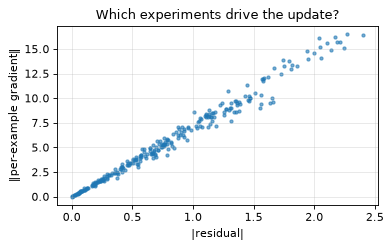

In [8]:
def loss_one(params, x, y):
    return (mlp(params, x[None, :])[0] - y) ** 2

per_ex = jax.jit(jax.vmap(jax.grad(loss_one), in_axes=(None, 0, 0)))
g_jax = per_ex(params, X[:256], y[:256])              # pytree with a leading batch axis of 256

from torch.func import functional_call, grad as tgrad, vmap as tvmap
tparams = {k: v.detach() for k, v in tmodel.named_parameters()}
def tloss_one(p, x, yy):
    return (functional_call(tmodel, p, (x[None, :],))[0, 0] - yy) ** 2
g_torch = tvmap(tgrad(tloss_one), in_dims=(None, 0, 0))(tparams, Xt[:256], yt[:256])

print("jax  per-example grad of layer-0 W:", g_jax["l0"]["w"].shape)
print("torch per-example grad of layer-0 W:", tuple(g_torch["0.weight"].shape))
print("max |difference|:", float(np.max(np.abs(np.asarray(g_jax["l0"]["w"]) - g_torch["0.weight"].numpy().transpose(0, 2, 1)))))
print("mean of per-example grads == full-batch grad:",
      np.allclose(np.asarray(g_jax["l0"]["w"]).mean(0), np.asarray(jax.grad(loss_fn)(params, X[:256], y[:256])["l0"]["w"])))

norms = np.sqrt(sum(np.sum(np.asarray(l).reshape(256, -1) ** 2, axis=1) for l in jax.tree_util.tree_leaves(g_jax)))
resid = np.abs(np.asarray(mlp(params, X[:256])) - y[:256])
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.scatter(resid, norms, s=8, alpha=0.6)
ax.set(xlabel="|residual|", ylabel="‖per-example gradient‖", title="Which experiments drive the update?")
plt.tight_layout(); plt.show()

## 5 · State: objects vs explicit pytrees

Train both implementations from the same initialisation with full-batch SGD + momentum. In
PyTorch, state lives *inside* objects (`tmodel` parameters, the optimizer's `momentum_buffer`)
and `opt.step()` mutates it. In JAX, the whole training state is a value — `(params, velocity)` —
that a pure `step` function maps to a new value. That is what makes checkpointing,
vmapping over hyper-parameters, or sharding the state natural in JAX, and why PyTorch needs
`state_dict()` / `load_state_dict()` (see `training/trainer.py` → `Trainer._payload`, which
also has to capture RNG state explicitly).

final loss torch 0.0531443329  jax 0.0531443329;  max |Δloss| over 150 steps = 1.1e-16


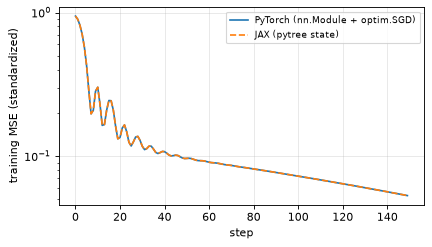

In [9]:
LR, MOM, STEPS = 0.05, 0.9, 150

# --- PyTorch: stateful objects
torch.manual_seed(0)
tm = nn.Sequential(nn.Linear(32, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1)).double()
p_init = params_from_torch(tm)                          # same init for JAX
topt = torch.optim.SGD(tm.parameters(), lr=LR, momentum=MOM)
torch_losses = []
for _ in range(STEPS):
    topt.zero_grad()
    loss = torch.mean((tm(Xt)[:, 0] - yt) ** 2); loss.backward(); topt.step()
    torch_losses.append(loss.item())

# --- JAX: explicit state pytree, pure update (same rule as torch.optim.SGD: v = mu*v + g; p -= lr*v)
@jax.jit
def train_step(state, x, y):
    params, vel = state
    loss, g = jax.value_and_grad(loss_fn)(params, x, y)
    vel = jax.tree_util.tree_map(lambda v, gi: MOM * v + gi, vel, g)
    params = jax.tree_util.tree_map(lambda p, v: p - LR * v, params, vel)
    return (params, vel), loss

state = (p_init, jax.tree_util.tree_map(jnp.zeros_like, p_init))
jax_losses = []
for _ in range(STEPS):
    state, loss = train_step(state, X, y)
    jax_losses.append(float(loss))

print(f"final loss torch {torch_losses[-1]:.10f}  jax {jax_losses[-1]:.10f};  "
      f"max |Δloss| over {STEPS} steps = {np.max(np.abs(np.array(torch_losses) - np.array(jax_losses))):.1e}")
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(torch_losses, label="PyTorch (nn.Module + optim.SGD)"); ax.plot(jax_losses, "--", label="JAX (pytree state)")
ax.set(yscale="log", xlabel="step", ylabel="training MSE (standardized)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Randomness is state, too

PyTorch's generator is global and mutated by every random op — which is why the repository's
`models/uncertainty.py` → `mc_dropout_predict` wraps MC dropout in `torch.random.fork_rng()` so
that uncertainty estimation does not perturb the training RNG stream, and why `Trainer` saves
`rng_state` in every checkpoint. JAX makes the key an explicit argument: same key → same mask,
and "advancing the stream" is an explicit `split`.

In [10]:
key = jax.random.PRNGKey(0)
k1, k2 = jax.random.split(key)
mask = lambda k: jax.random.bernoulli(k, 0.5, (8,)).astype(int)
print("key k1:", mask(k1), " again k1:", mask(k1), " k2:", mask(k2))
torch.manual_seed(0); a = (torch.rand(8) < 0.5).int(); b = (torch.rand(8) < 0.5).int()
print("torch, same seed, two calls:", a.tolist(), b.tolist(), "(global state advanced)")

key k1: [0 1 0 0 1 1 0 1]  again k1: [0 1 0 0 1 1 0 1]  k2: [1 0 0 0 0 0 0 0]
torch, same seed, two calls: [1, 0, 1, 1, 1, 0, 1, 0] [1, 0, 1, 1, 1, 1, 1, 0] (global state advanced)


## 6 · Sharded execution on 4 (virtual) CPU devices

`XLA_FLAGS=--xla_force_host_platform_device_count=4` (set in the first cell, before importing
JAX) splits the CPU into 4 XLA devices — enough to see real sharding semantics without GPUs.
We build a 1-D **mesh** with axis `"data"`, shard the batch along it, replicate the parameters,
and jit the same `train_step`. This is data parallelism — the JAX analogue of DDP.

In [11]:
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P

mesh = Mesh(np.array(jax.devices()), axis_names=("data",))
data_sh = NamedSharding(mesh, P("data"))          # split rows across devices
repl = NamedSharding(mesh, P())                    # replicate on every device

Xs = jax.device_put(X, data_sh); ys = jax.device_put(y, data_sh)
state0 = jax.device_put((p_init, jax.tree_util.tree_map(jnp.zeros_like, p_init)), repl)
print("X sharding:", Xs.sharding.spec, "| shard shapes:", [s.data.shape for s in Xs.addressable_shards],
      "| devices:", [str(s.device) for s in Xs.addressable_shards])

state_sh, loss_sh = train_step(state0, Xs, ys)
state_1, loss_1 = train_step((p_init, jax.tree_util.tree_map(jnp.zeros_like, p_init)), X, y)
diff = max(float(jnp.max(jnp.abs(a - b))) for a, b in
           zip(jax.tree_util.tree_leaves(state_sh), jax.tree_util.tree_leaves(state_1)))
print(f"sharded vs single-device step: loss {float(loss_sh):.12f} vs {float(loss_1):.12f}; max |Δparam| = {diff:.1e}")
print("updated params are replicated:", jax.tree_util.tree_leaves(state_sh)[0].sharding.spec)

hlo = train_step.lower(state0, Xs, ys).compile().as_text()
print("collectives inserted by the compiler:",
      {op: hlo.count(op) for op in ("all-reduce", "all-gather", "reduce-scatter") if op in hlo})

X sharding: P('data',) | shard shapes: [(256, 32), (256, 32), (256, 32), (256, 32)] | devices: ['cpu:0', 'cpu:1', 'cpu:2', 'cpu:3']


sharded vs single-device step: loss 0.943778866321 vs 0.943778866321; max |Δparam| = 2.5e-16
updated params are replicated: P()
collectives inserted by the compiler: {'all-reduce': 9}


The compiler inserted the **all-reduce** that DDP performs in `loss.backward()`: each device
computes the gradient of its shard of the batch, the partial gradients are summed, and every
device applies the same update to its replica.

The same annotation mechanism expresses **model (tensor) parallelism** — shard a weight matrix
instead of the batch — without changing the model code:

In [12]:
w_sh = NamedSharding(mesh, P(None, "data"))                     # split layer-1 output units over devices
p_tp = dict(p_init); p_tp["l1"] = {"w": jax.device_put(p_init["l1"]["w"], w_sh), "b": p_init["l1"]["b"]}
print("layer-1 weight shards:", [s.data.shape for s in p_tp["l1"]["w"].addressable_shards])
out = jax.jit(mlp)(p_tp, X)
print("tensor-parallel forward == single device:", bool(jnp.allclose(out, mlp(p_init, X))))

layer-1 weight shards: [(64, 16), (64, 16), (64, 16), (64, 16)]
tensor-parallel forward == single device: True


| Concern | PyTorch DDP (this repository) | JAX sharding |
|---|---|---|
| unit of parallelism | one **process** per rank (`torch.distributed`, launched by Ray Train) | one **program** over a device mesh (multi-host: one process per host) |
| who inserts collectives | DDP hooks during `backward()` (bucketed all-reduce) | the XLA SPMD partitioner, from sharding annotations |
| model / tensor parallel | separate libraries / manual (FSDP, TP) | same annotations on parameter arrays |
| where it appears here | `training/trainer.py` → `Trainer.setup` wraps `DistributedDataParallel`; `training/distributed.py` → `train_distributed` | this notebook only |

## Connection to this repository

* The training stack is PyTorch only: `src/bci_platform/models/mlp.py` (`ResidualMLP`,
  `build_model`), `src/bci_platform/training/trainer.py` (`Trainer`, DDP wrapping,
  `DistributedSampler`, all-reduced validation statistics), `src/bci_platform/training/distributed.py`
  (`train_distributed`: Ray decides *where* workers run, DDP decides *how* gradients sync).
* Explicit state in an object world: `Trainer._payload` / `load_checkpoint` capture model,
  optimizer, normaliser and **RNG state** (`training/config.py` → `get_rng_state`, `set_rng_state`) —
  what JAX would carry as one pytree.
* Functional RNG discipline in PyTorch: `models/uncertainty.py` → `mc_dropout_predict` uses
  `torch.random.fork_rng` and an explicit seed.
* Standardisation used above: `data/normalization.py` → `Normalizer`.
* **Why not a second training stack?** Two stacks double the surface for checkpoint formats,
  determinism, distributed launch, serving and evaluation parity — for no gain on this problem.
  The design keeps model code framework-local (`models/`, `training/`) behind narrow interfaces
  (`Predictor`, `TrainResult`, checkpoints), so a JAX model *could* be added later without
  touching orchestration, but it would have to reproduce those contracts.

## Failure modes

* **Retracing storms** under `jit` from changing shapes, Python scalars used as static values, or
  non-hashable static args — each costs a compile.
* **Side effects inside `jit`** (printing, appending to lists, reading globals) run once at trace
  time, not per call — see `TRACES` above.
* **Hidden state in PyTorch** — global RNG, `model.train()`/`eval()` mode, optimizer buffers:
  forgetting any of them breaks reproducibility or resume (`Trainer` checkpoints all of them).
* **Numerics across frameworks** — agreement to 1e-15 needs float64 and identical op order; in
  float32 expect ~1e-6, and more after fused/compiled kernels reorder reductions.
* **Silent replication** — an unannotated array in a sharded `jit` may be replicated on every
  device (memory × N); check `.sharding` of large arrays.
* **Implicit host↔device sync** — `float(loss)` or `.item()` every step serialises asynchronous
  dispatch in both frameworks.

## Exercise

1. Add dropout to the JAX `mlp` using an explicit `key` argument and implement MC-dropout
   prediction with `jax.vmap` over 30 split keys. Compare the result's std with
   `bci_platform.models.mc_dropout_predict` on a PyTorch model with the same weights (masks will
   differ; distributions should not).
2. Use `jax.vmap` over a *learning-rate axis* to train 8 copies of the model with different
   learning rates in one jitted call. What would the PyTorch equivalent look like?
3. Shard the batch over a 2×2 mesh `("data", "model")`, with layer weights split on `"model"`.
   Which collectives appear in the compiled HLO now?

In [13]:
import shutil
shutil.rmtree(WORK, ignore_errors=True)
print(f"done in {time.perf_counter() - T0:.1f}s; workspace removed (no Ray used in this notebook)")

done in 5.6s; workspace removed (no Ray used in this notebook)
